In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import joblib

In [2]:
df_t1 = pd.read_csv(r"C:\Users\Ricardo\TFG_ENTREGAR\data\end\final_csv_t1.csv")
df_t5 = pd.read_csv(r"c:\Users\Ricardo\TFG_ENTREGAR\data\end\final_csv_t5.csv")

In [3]:
print(df_t1.columns)

Index(['Unnamed: 0', 'Date', 'Price Close', 'Ticker', 'pais', 'finbert_score',
       'ret_intradiario', 'ret_t1', 'finbert_score_acc_5-1',
       'finbert_score_acc_20-6', 'ret_hist_5_1', 'ret_hist_20_6',
       'dist_ma_5_1', 'dist_ma_20_6', 'vol_historica', 'vol_acc_20-6',
       'vol_acc_5', 'bond_spread', 'bond_spread_chg_1d', 'bond_spread_chg_5_1',
       'bond_spread_chg_20_6', 'rsi_14', 'rel_vol_252', 'rel_vol_acc_5_1'],
      dtype='object')


In [4]:
# ============================================================
# PONDERACIÓN IGUALITARIA POR GRUPO GEOGRÁFICO
# Cada grupo vale 1/3 del total
# ============================================================

# --- Definición de grupos ---
grupo_eeuu    = ['BAC', 'C.N', 'GS', 'JPM', 'MS']
grupo_uk      = ['BARC.L', 'HSBA.L']
grupo_europa  = ['CRDI.MI', 'DBKGn.DE']

peso_por_grupo = 1/3

# Peso individual por ticker dentro de cada grupo
pesos = {}

for ticker in grupo_eeuu:
    pesos[ticker] = peso_por_grupo / len(grupo_eeuu)   # 1/3 / 5 = 0.0667

for ticker in grupo_uk:
    pesos[ticker] = peso_por_grupo / len(grupo_uk)     # 1/3 / 2 = 0.1667

for ticker in grupo_europa:
    pesos[ticker] = peso_por_grupo / len(grupo_europa) # 1/3 / 2 = 0.1667

# --- Verificación ---
print("=" * 45)
print("  PESOS POR TICKER")
print("=" * 45)
print(f"  {'Ticker':<12} {'Grupo':<10} {'Peso':>8}")
print("-" * 45)
for ticker, peso in pesos.items():
    grupo = 'EEUU' if ticker in grupo_eeuu else ('UK' if ticker in grupo_uk else 'Europa')
    print(f"  {ticker:<12} {grupo:<10} {peso:>8.4f}")
print("-" * 45)
print(f"  {'TOTAL':<22} {sum(pesos.values()):>8.4f}")
print("=" * 45)

# --- Aplicar al dataframe ---
# Añade columna de peso a df_t1 y df_t5
for df in [df_t1, df_t5]:
    df['peso'] = df['Ticker'].map(pesos)

  PESOS POR TICKER
  Ticker       Grupo          Peso
---------------------------------------------
  BAC          EEUU         0.0667
  C.N          EEUU         0.0667
  GS           EEUU         0.0667
  JPM          EEUU         0.0667
  MS           EEUU         0.0667
  BARC.L       UK           0.1667
  HSBA.L       UK           0.1667
  CRDI.MI      Europa       0.1667
  DBKGn.DE     Europa       0.1667
---------------------------------------------
  TOTAL                    1.0000


In [5]:
X_cols = ['finbert_score',
      'ret_intradiario', 'finbert_score_acc_5-1', 'finbert_score_acc_20-6',
      'ret_hist_5_1', 'ret_hist_20_6', 'dist_ma_5_1', 'dist_ma_20_6',
      'vol_historica', 'vol_acc_20-6', 'vol_acc_5', 'bond_spread',
      'bond_spread_chg_1d', 'bond_spread_chg_5_1', 'bond_spread_chg_20_6',
      'rsi_14', 'rel_vol_252', 'rel_vol_acc_5_1']

def prepare_temporal_split(data, target_col, features):
    """
    Ordena por fecha, realiza un split 80/20 y limpia NaNs SOLO de la columna Target.
    """
    # 1. Aseguramos formato fecha y orden temporal estricto
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.sort_values(by='Date').reset_index(drop=True)
    
    # 2. Limpieza de NaNs SOLO en el Target
    # Mantenemos las filas con features incompletas, pero borramos si no hay qué predecir
    data_clean = data.dropna(subset=[target_col]).copy()
    
    # 3. Definimos punto de corte (80% train, 20% test)
    split_index = int(len(data_clean) * 0.80)
    
    # 4. Creación de subconjuntos
    df_train = data_clean.iloc[:split_index]
    df_test = data_clean.iloc[split_index:]
    
    # 5. Separación X e y
    X_train = df_train[features]
    y_train = df_train[target_col]
    
    X_test = df_test[features]
    y_test = df_test[target_col]
    
    # 6. Verificación
    print(f"--- División Temporal: [{target_col}] ---")
    print(f"Registros útiles (limpiando NaNs en TARGET): {len(data_clean)}")
    print(f"Train: {X_train.shape[0]} filas ({df_train['Date'].min().date()} a {df_train['Date'].max().date()})")
    print(f"Test:  {X_test.shape[0]} filas ({df_test['Date'].min().date()} a {df_test['Date'].max().date()})")
    
    # Aviso sobre las Features (X)
    nan_in_X = X_train.isna().sum().sum() + X_test.isna().sum().sum()
    if nan_in_X > 0:
        print(f"¡AVISO!: Hay {nan_in_X} valores NaN en las features (X).")
        print("El DecisionTreeClassifier fallará si no rellenas estos huecos (ej: .fillna(0)).")
    
    print("-" * 40 + "\n")
    
    return X_train, X_test, y_train, y_test

# --- LLAMADAS ---

# 1. Para el dataset diario (ret_t1)
X_train_t1, X_test_t1, y_train_t1, y_test_t1 = prepare_temporal_split(df_t1, 'ret_t1', X_cols)

# 2. Para el dataset sin solapamiento (ret_t5)
X_train_t5, X_test_t5, y_train_t5, y_test_t5 = prepare_temporal_split(df_t5, 'ret_t5', X_cols)


# ============================================================
# SAMPLE WEIGHTS PARA TRAIN — T1 y T5
# ============================================================

# --- T5 ---
df_ml_t5 = df_t5.dropna(subset=['ret_t5']).copy()
df_ml_t5 = df_ml_t5.sort_values('Date').reset_index(drop=True)
df_ml_t5['peso'] = df_ml_t5['Ticker'].map(pesos)
split_idx_t5 = int(len(df_ml_t5) * 0.8)
sw_train_t5 = df_ml_t5['peso'].iloc[:split_idx_t5].values

# --- T1 ---
df_ml_t1 = df_t1.dropna(subset=['ret_t1']).copy()
df_ml_t1 = df_ml_t1.sort_values('Date').reset_index(drop=True)
df_ml_t1['peso'] = df_ml_t1['Ticker'].map(pesos)
split_idx_t1 = int(len(df_ml_t1) * 0.8)
sw_train_t1 = df_ml_t1['peso'].iloc[:split_idx_t1].values

# --- Verificación ---
print(f"sw_train_t5: {len(sw_train_t5)} pesos | X_train_t5: {len(X_train_t5)} filas | {'OK' if len(sw_train_t5) == len(X_train_t5) else ' DESALINEADO'}")
print(f"sw_train_t1: {len(sw_train_t1)} pesos | X_train_t1: {len(X_train_t1)} filas | {'OK' if len(sw_train_t1) == len(X_train_t1) else ' DESALINEADO'}")

# Clasificación binaria: convertir y a 0/1
y_train_t1_clf = (y_train_t1 > 0).astype(int)
y_test_t1_clf  = (y_test_t1  > 0).astype(int)
y_train_t5_clf = (y_train_t5 > 0).astype(int)
y_test_t5_clf  = (y_test_t5  > 0).astype(int)

--- División Temporal: [ret_t1] ---
Registros útiles (limpiando NaNs en TARGET): 46050
Train: 36840 filas (2004-02-02 a 2022-02-02)
Test:  9210 filas (2022-02-02 a 2026-02-25)
----------------------------------------

--- División Temporal: [ret_t5] ---
Registros útiles (limpiando NaNs en TARGET): 8737
Train: 6989 filas (2004-02-02 a 2022-04-12)
Test:  1748 filas (2022-04-12 a 2026-02-19)
----------------------------------------

sw_train_t5: 6989 pesos | X_train_t5: 6989 filas | OK
sw_train_t1: 36840 pesos | X_train_t1: 36840 filas | OK


In [6]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

def run_regression_check_dw(data, target_col, features):
    y = data[target_col]
    X = sm.add_constant(data[features])
    
    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': data['Ticker']})
    
    # DW global (referencial, sesgado por orden entre tickers)
    dw_global = durbin_watson(model.resid)
    print(f"\nDurbin-Watson GLOBAL (referencial): {dw_global:.4f}")
    print("  Este valor está sesgado por el orden entre tickers\n")
    
    # DW por ticker (el correcto)
    print(f"Durbin-Watson POR TICKER — {target_col}:")
    print("-" * 40)
    dw_values = []
    df_with_resid = data.copy()
    df_with_resid['residuo'] = model.resid.values

    for ticker, grupo in df_with_resid.groupby('Ticker'):
        if len(grupo) > 10:
            dw_t = durbin_watson(grupo['residuo'].values)
            dw_values.append(dw_t)
            estado = "" if 1.5 < dw_t < 2.5 else ""
            print(f"  {ticker:<12} DW = {dw_t:.4f}  {estado}")

    dw_media = np.mean(dw_values)
    print("-" * 40)
    print(f"  {'MEDIA':<12} DW = {dw_media:.4f}  {'' if 1.5 < dw_media < 2.5 else ''}")
    print()

    return model

features = [
    'finbert_score', 'ret_intradiario', 'finbert_score_acc_5-1', 'finbert_score_acc_20-6',
    'ret_hist_5_1', 'ret_hist_20_6', 'dist_ma_5_1', 'dist_ma_20_6',
    'vol_historica', 'vol_acc_20-6', 'vol_acc_5', 'bond_spread',
    'bond_spread_chg_1d', 'bond_spread_chg_5_1', 'bond_spread_chg_20_6',
    'rsi_14', 'rel_vol_252', 'rel_vol_acc_5_1'
]

model_t5 = run_regression_check_dw(df_t5, 'ret_t5', features)
model_t1 = run_regression_check_dw(df_t1, 'ret_t1', features)


Durbin-Watson GLOBAL (referencial): 1.1214
  Este valor está sesgado por el orden entre tickers

Durbin-Watson POR TICKER — ret_t5:
----------------------------------------
  BAC          DW = 1.9041  
  BARC.L       DW = 2.0037  
  C.N          DW = 1.9660  
  CRDI.MI      DW = 1.9584  
  DBKGn.DE     DW = 1.8374  
  GS           DW = 1.8952  
  HSBA.L       DW = 2.0513  
  JPM          DW = 1.9244  
  MS           DW = 1.9510  
----------------------------------------
  MEDIA        DW = 1.9435  


Durbin-Watson GLOBAL (referencial): 1.1572
  Este valor está sesgado por el orden entre tickers

Durbin-Watson POR TICKER — ret_t1:
----------------------------------------
  BAC          DW = 1.9768  
  BARC.L       DW = 2.0483  
  C.N          DW = 1.9443  
  CRDI.MI      DW = 2.0063  
  DBKGn.DE     DW = 1.9645  
  GS           DW = 2.0031  
  HSBA.L       DW = 2.0483  
  JPM          DW = 2.0670  
  MS           DW = 1.9986  
----------------------------------------
  MEDIA        DW 

--- RESULTADOS: T+1 Diario ---
Train Accuracy: 0.5272
Test Accuracy:  0.5050

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.47      0.45      0.46      4280
           1       0.54      0.55      0.54      4930

    accuracy                           0.50      9210
   macro avg       0.50      0.50      0.50      9210
weighted avg       0.50      0.50      0.50      9210



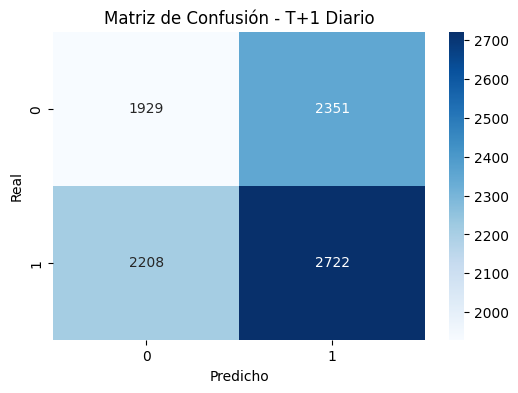

--- RESULTADOS: T+5 Sin Solape ---
Train Accuracy: 0.5670
Test Accuracy:  0.4634

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.38      0.50      0.43       722
           1       0.55      0.44      0.49      1026

    accuracy                           0.46      1748
   macro avg       0.47      0.47      0.46      1748
weighted avg       0.48      0.46      0.47      1748



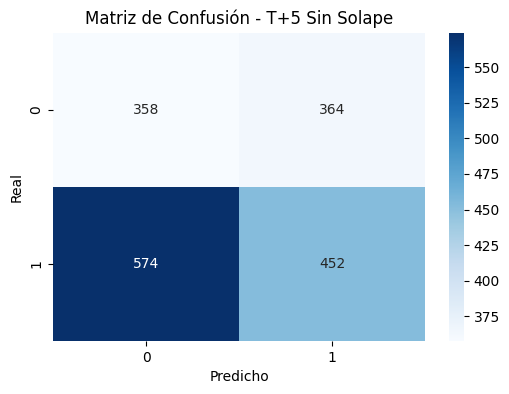

In [7]:
# ============================================================
# DECISION TREE CLASSIFIER
# ============================================================
def train_evaluate_tree(X_train, X_test, y_train, y_test,
                         title, max_depth, min_samples_leaf, sample_wheight):

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=42
    )
    clf.fit(X_train, y_train, sample_weight=sample_wheight)

    y_pred_train = clf.predict(X_train)
    y_pred_test  = clf.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)
    cm        = confusion_matrix(y_test, y_pred_test)

    print(f"--- RESULTADOS: {title} ---")
    print(f"Train Accuracy: {acc_train:.4f}")
    print(f"Test Accuracy:  {acc_test:.4f}")
    print("\nReporte de Clasificación (Test):")
    print(classification_report(y_test, y_pred_test))

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Matriz de Confusión - {title}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
    plt.show()

    return clf

# --- EJECUCIÓN ---

X_cols = [
    'finbert_score', 'ret_intradiario', 'finbert_score_acc_5-1', 'finbert_score_acc_20-6',
    'ret_hist_5_1', 'ret_hist_20_6', 'dist_ma_5_1', 'dist_ma_20_6',
    'vol_historica', 'vol_acc_20-6', 'vol_acc_5', 'bond_spread',
    'bond_spread_chg_1d', 'bond_spread_chg_5_1', 'bond_spread_chg_20_6',
    'rsi_14', 'rel_vol_252', 'rel_vol_acc_5_1'
]

dt_clf_t1 = train_evaluate_tree(X_train_t1, X_test_t1, y_train_t1_clf, y_test_t1_clf,
                                 "T+1 Diario", max_depth=18, min_samples_leaf=2000, sample_wheight=sw_train_t1)
dt_clf_t5 = train_evaluate_tree(X_train_t5, X_test_t5, y_train_t5_clf, y_test_t5_clf,
                                 "T+5 Sin Solape", max_depth=9, min_samples_leaf=200, sample_wheight=sw_train_t5)

--- RESULTADOS RF CLASIFICACIÓN: T+1 Diario ---
Parámetros: Trees=75, Depth=18, Leaf=2000
Train Accuracy: 0.5248
Test Accuracy:  0.4832

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.46      0.63      0.53      4280
           1       0.53      0.36      0.43      4930

    accuracy                           0.48      9210
   macro avg       0.49      0.49      0.48      9210
weighted avg       0.49      0.48      0.47      9210

Top 5 features:
dist_ma_5_1        0.124919
vol_acc_20-6       0.089797
ret_intradiario    0.088506
rel_vol_252        0.083124
vol_acc_5          0.082547
dtype: float64



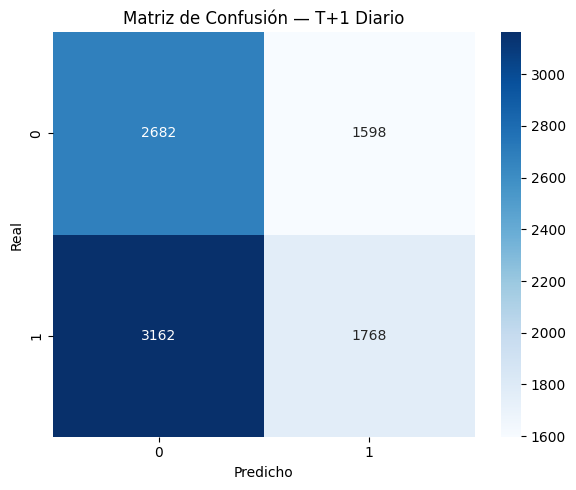

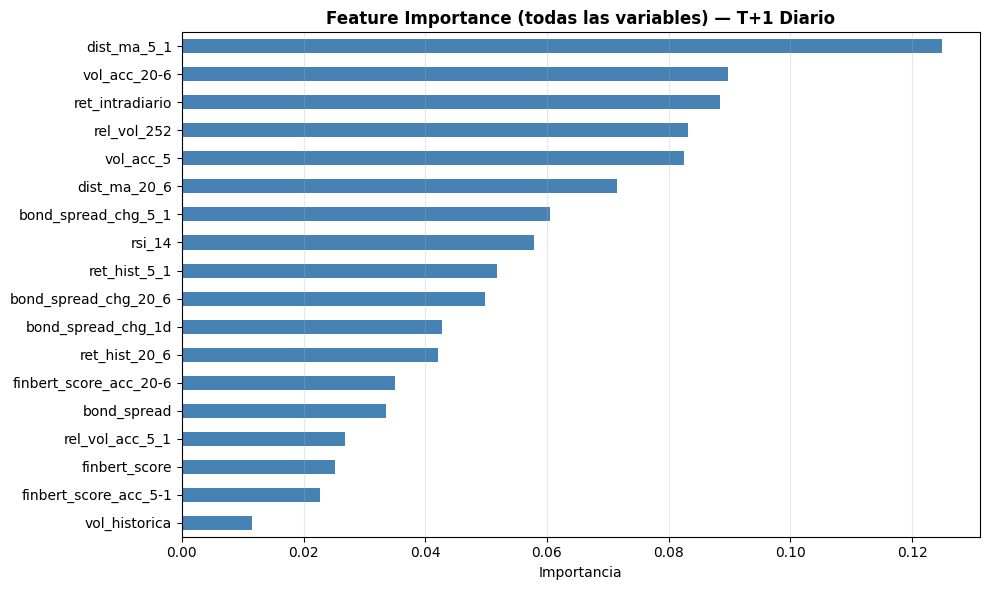

--- RESULTADOS RF CLASIFICACIÓN: T+5 Sin Solape ---
Parámetros: Trees=75, Depth=9, Leaf=200
Train Accuracy: 0.5690
Test Accuracy:  0.5034

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.43      0.57      0.49       722
           1       0.60      0.45      0.52      1026

    accuracy                           0.50      1748
   macro avg       0.51      0.51      0.50      1748
weighted avg       0.53      0.50      0.51      1748

Top 5 features:
vol_acc_5          0.105022
ret_hist_5_1       0.080955
vol_acc_20-6       0.077002
dist_ma_5_1        0.073079
ret_intradiario    0.072291
dtype: float64



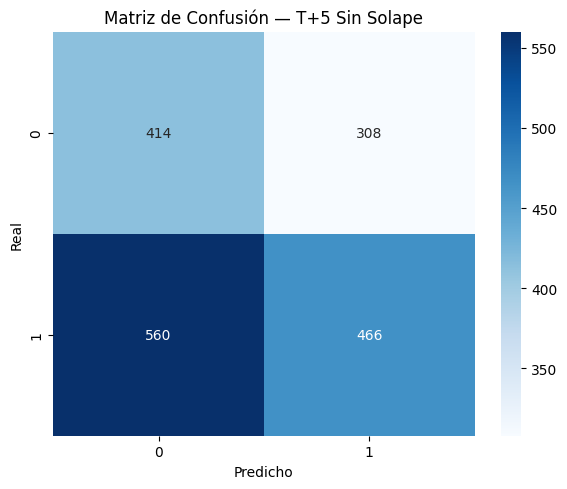

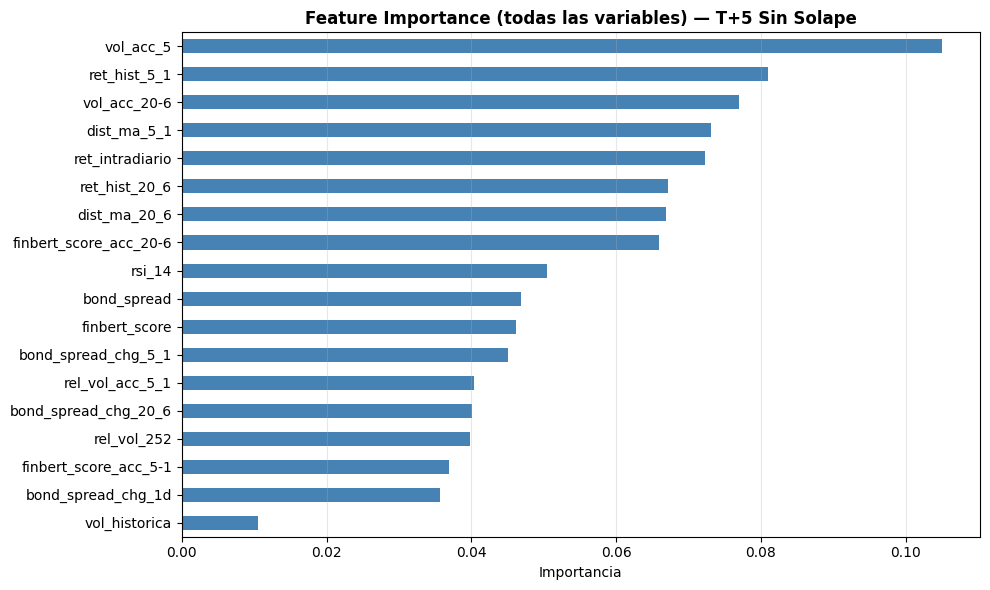

In [17]:
def train_evaluate_rf_classifier(X_train, X_test, y_train, y_test,
                                  title, max_depth, min_samples_leaf, sample_weight, n_estimators=75):

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    clf.fit(X_train, y_train, sample_weight=sample_weight)

    y_pred_train = clf.predict(X_train)
    y_pred_test  = clf.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)
    cm        = confusion_matrix(y_test, y_pred_test)

    print(f"--- RESULTADOS RF CLASIFICACIÓN: {title} ---")
    print(f"Parámetros: Trees={n_estimators}, Depth={max_depth}, Leaf={min_samples_leaf}")
    print(f"Train Accuracy: {acc_train:.4f}")
    print(f"Test Accuracy:  {acc_test:.4f}")
    print("\nReporte de Clasificación (Test):")
    print(classification_report(y_test, y_pred_test))

    importances = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print(f"Top 5 features:\n{importances.head()}\n")

    # --- Gráfico 1: Matriz de confusión ---
    fig1, ax1 = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set_title(f'Matriz de Confusión — {title}')
    ax1.set_ylabel('Real')
    ax1.set_xlabel('Predicho')
    plt.tight_layout()
    plt.show()

    # --- Gráfico 2: Feature Importance (todas las variables) ---
    n_features = len(importances)
    fig_height = max(6, n_features * 0.3)
    fig2, ax2 = plt.subplots(figsize=(10, fig_height))
    importances.plot(kind='barh', ax=ax2, color='steelblue')
    ax2.invert_yaxis()
    ax2.set_title(f'Feature Importance (todas las variables) — {title}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Importancia')
    ax2.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    return clf

# --- RF Classifier ---
rf_clf_t1 = train_evaluate_rf_classifier(X_train_t1, X_test_t1, y_train_t1_clf, y_test_t1_clf,
                                          "T+1 Diario", max_depth=18, min_samples_leaf=2000, sample_weight=sw_train_t1)
rf_clf_t5 = train_evaluate_rf_classifier(X_train_t5, X_test_t5, y_train_t5_clf, y_test_t5_clf,
                                          "T+5 Sin Solape", max_depth=9, min_samples_leaf=200, sample_weight=sw_train_t5) #NO TOCAR 9 200

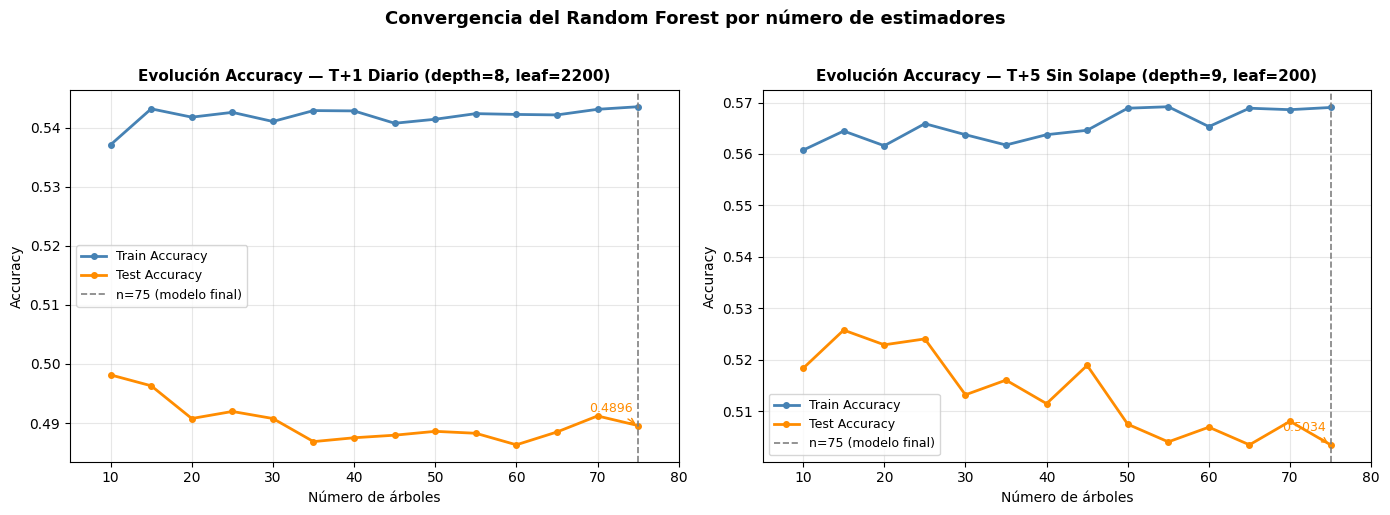

In [23]:
# ── Evolución del Accuracy según número de árboles ──────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

tree_range = list(range(10, 76, 5))

def accuracy_curve(X_train, X_test, y_train, y_test,
                   max_depth, min_samples_leaf, sample_weight, tree_range):
    train_accs, test_accs = [], []
    for n in tree_range:
        clf = RandomForestClassifier(
            n_estimators=n,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced",
            max_features='sqrt',
            n_jobs=-1,
            random_state=42
        )
        clf.fit(X_train, y_train, sample_weight=sample_weight)
        train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
        test_accs.append(accuracy_score(y_test,  clf.predict(X_test)))
    return train_accs, test_accs

# Calcular curvas para ambos targets
train_t1, test_t1 = accuracy_curve(
    X_train_t1, X_test_t1, y_train_t1_clf, y_test_t1_clf,
    max_depth=18, min_samples_leaf=1000,
    sample_weight=sw_train_t1, tree_range=tree_range
)

train_t5, test_t5 = accuracy_curve(
    X_train_t5, X_test_t5, y_train_t5_clf, y_test_t5_clf,
    max_depth=9, min_samples_leaf=200,
    sample_weight=sw_train_t5, tree_range=tree_range
)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_accs, test_accs, title in zip(
    axes,
    [train_t1, train_t5],
    [test_t1,  test_t5],
    ["T+1 Diario (depth=8, leaf=2200)",
     "T+5 Sin Solape (depth=9, leaf=200)"]
):
    ax.plot(tree_range, train_accs, label="Train Accuracy",
            color="steelblue", linewidth=2, marker='o', markersize=4)
    ax.plot(tree_range, test_accs,  label="Test Accuracy",
            color="darkorange", linewidth=2, marker='o', markersize=4)

    # Línea vertical en n=200
    ax.axvline(x=75, color="gray", linestyle="--", linewidth=1.2, label="n=75 (modelo final)")

    # Anotar accuracy final en test
    ax.annotate(f"{test_accs[-1]:.4f}",
                xy=(75, test_accs[-1]),
                xytext=(-35, 10), textcoords="offset points",
                fontsize=9, color="darkorange",
                arrowprops=dict(arrowstyle="->", color="darkorange", lw=1))

    ax.set_title(f"Evolución Accuracy — {title}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Número de árboles")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(tree_range[0] - 5, tree_range[-1] + 5)

plt.suptitle("Convergencia del Random Forest por número de estimadores",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

--- RESULTADOS RF CLASIFICACIÓN: T+1 Diario ---
Parámetros: Trees=75, Depth=18, Leaf=2000
Umbrales: Baja < 0.47  |  Incierto [0.47, 0.53]  |  Sube > 0.53

Distribución predicciones test:
  Baja     :   213  (2.3%)
  Incierto :  8814  (95.7%)  ← no cuenta en accuracy
  Sube     :   183  (2.0%)

Accuracy solo sobre decisiones tomadas (396 obs de 9210):
  Train : 0.6106
  Test  : 0.5227

Reporte de Clasificación (Test — solo decididos):
              precision    recall  f1-score   support

        Baja       0.54      0.56      0.55       208
        Sube       0.50      0.48      0.49       188

    accuracy                           0.52       396
   macro avg       0.52      0.52      0.52       396
weighted avg       0.52      0.52      0.52       396

Top 5 features:
dist_ma_5_1        0.124919
vol_acc_20-6       0.089797
ret_intradiario    0.088506
rel_vol_252        0.083124
vol_acc_5          0.082547
dtype: float64



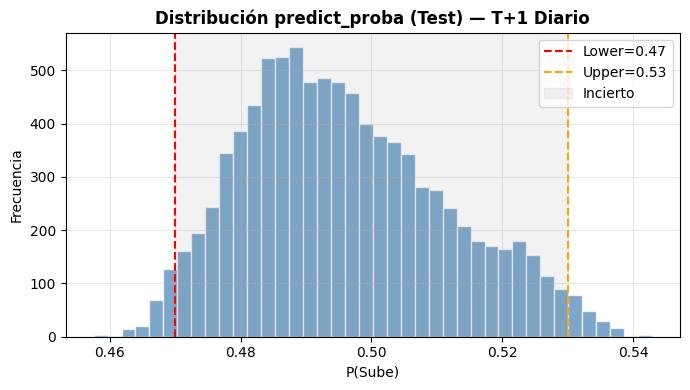

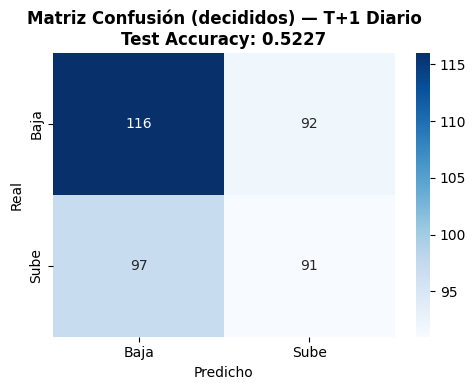

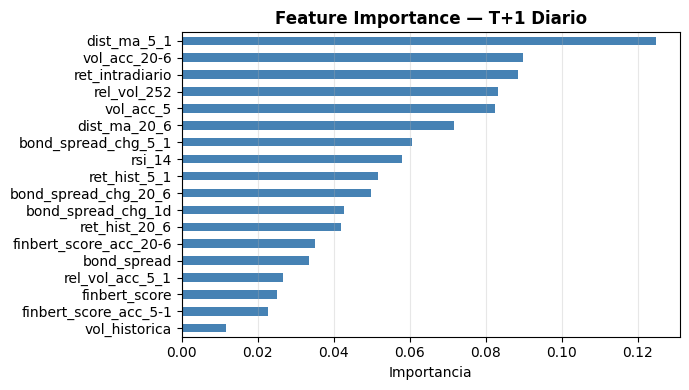

--- RESULTADOS RF CLASIFICACIÓN: T+5 Sin Solape ---
Parámetros: Trees=75, Depth=9, Leaf=200
Umbrales: Baja < 0.47  |  Incierto [0.47, 0.52]  |  Sube > 0.52

Distribución predicciones test:
  Baja     :   397  (22.7%)
  Incierto :   942  (53.9%)  ← no cuenta en accuracy
  Sube     :   409  (23.4%)

Accuracy solo sobre decisiones tomadas (806 obs de 1748):
  Train : 0.6143
  Test  : 0.5409

Reporte de Clasificación (Test — solo decididos):
              precision    recall  f1-score   support

        Baja       0.45      0.54      0.49       329
        Sube       0.63      0.54      0.58       477

    accuracy                           0.54       806
   macro avg       0.54      0.54      0.54       806
weighted avg       0.56      0.54      0.54       806

Top 5 features:
vol_acc_5          0.105022
ret_hist_5_1       0.080955
vol_acc_20-6       0.077002
dist_ma_5_1        0.073079
ret_intradiario    0.072291
dtype: float64



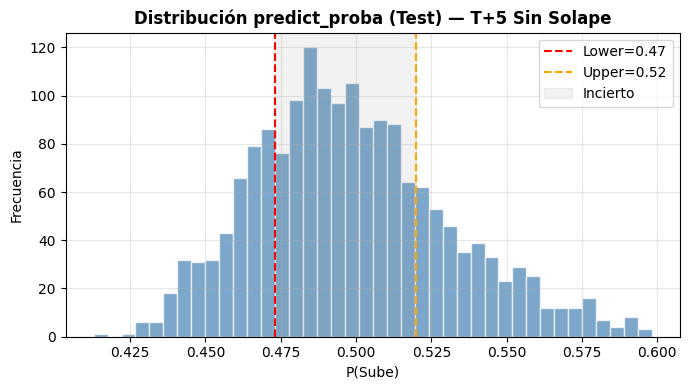

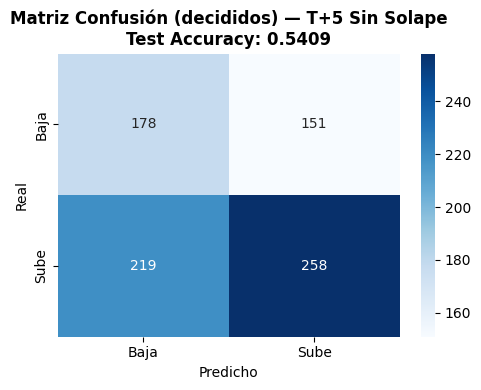

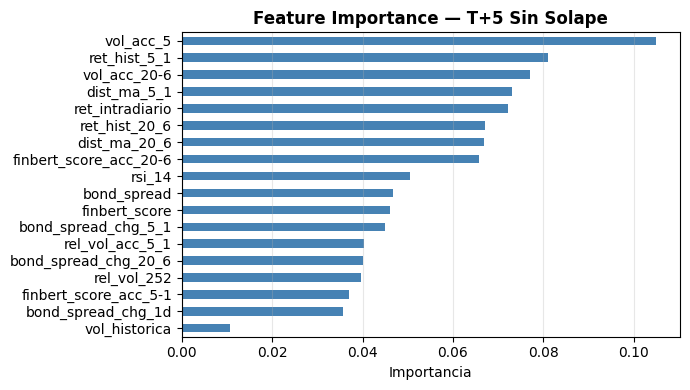

In [33]:
def train_evaluate_rf_classifier(X_train, X_test, y_train, y_test,
                                  title, max_depth, min_samples_leaf, sample_weight,
                                  n_estimators=75,
                                  lower_threshold=0.45,
                                  upper_threshold=0.55):
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    clf.fit(X_train, y_train, sample_weight=sample_weight)

    proba_train = clf.predict_proba(X_train)[:, 1]
    proba_test  = clf.predict_proba(X_test)[:, 1]

    def apply_thresholds(proba):
        return np.where(proba < lower_threshold, 0,
               np.where(proba > upper_threshold, 1, 2))

    y_pred_train_3 = apply_thresholds(proba_train)
    y_pred_test_3  = apply_thresholds(proba_test)

    mask_train = y_pred_train_3 != 2
    mask_test  = y_pred_test_3  != 2

    acc_train = accuracy_score(y_train[mask_train], y_pred_train_3[mask_train]) if mask_train.sum() > 0 else 0
    acc_test  = accuracy_score(y_test[mask_test],   y_pred_test_3[mask_test])   if mask_test.sum()  > 0 else 0

    n_baja     = (y_pred_test_3 == 0).sum()
    n_incierto = (y_pred_test_3 == 2).sum()
    n_sube     = (y_pred_test_3 == 1).sum()
    total      = len(y_pred_test_3)

    print(f"--- RESULTADOS RF CLASIFICACIÓN: {title} ---")
    print(f"Parámetros: Trees={n_estimators}, Depth={max_depth}, Leaf={min_samples_leaf}")
    print(f"Umbrales: Baja < {lower_threshold:.2f}  |  Incierto [{lower_threshold:.2f}, {upper_threshold:.2f}]  |  Sube > {upper_threshold:.2f}")
    print(f"\nDistribución predicciones test:")
    print(f"  Baja     : {n_baja:>5}  ({n_baja/total:.1%})")
    print(f"  Incierto : {n_incierto:>5}  ({n_incierto/total:.1%})  ← no cuenta en accuracy")
    print(f"  Sube     : {n_sube:>5}  ({n_sube/total:.1%})")
    print(f"\nAccuracy solo sobre decisiones tomadas ({mask_test.sum()} obs de {total}):")
    print(f"  Train : {acc_train:.4f}")
    print(f"  Test  : {acc_test:.4f}")
    print(f"\nReporte de Clasificación (Test — solo decididos):")
    print(classification_report(y_test[mask_test], y_pred_test_3[mask_test],
                                target_names=['Baja', 'Sube']))

    importances = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print(f"Top 5 features:\n{importances.head()}\n")

    # --- Gráfico 1: Histograma de probabilidades ---
    fig1, ax1 = plt.subplots(figsize=(7, 4))
    ax1.hist(proba_test, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax1.axvline(lower_threshold, color='red',    linestyle='--', linewidth=1.5,
                label=f'Lower={lower_threshold:.2f}')
    ax1.axvline(upper_threshold, color='orange', linestyle='--', linewidth=1.5,
                label=f'Upper={upper_threshold:.2f}')
    ax1.axvspan(lower_threshold, upper_threshold, alpha=0.1, color='grey', label='Incierto')
    ax1.set_title(f'Distribución predict_proba (Test) — {title}', fontweight='bold')
    ax1.set_xlabel('P(Sube)')
    ax1.set_ylabel('Frecuencia')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Gráfico 2: Matriz de confusión ---
    if mask_test.sum() > 0:
        fig2, ax2 = plt.subplots(figsize=(5, 4))
        cm = confusion_matrix(y_test[mask_test], y_pred_test_3[mask_test])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                    xticklabels=['Baja', 'Sube'], yticklabels=['Baja', 'Sube'])
        ax2.set_title(f'Matriz Confusión (decididos) — {title}\nTest Accuracy: {acc_test:.4f}',
                      fontweight='bold')
        ax2.set_ylabel('Real')
        ax2.set_xlabel('Predicho')
        plt.tight_layout()
        plt.show()

    # --- Gráfico 3: Feature importance ---
    fig3, ax3 = plt.subplots(figsize=(7, 4))
    importances.plot(kind='barh', ax=ax3, color='steelblue')
    ax3.invert_yaxis()
    ax3.set_title(f'Feature Importance — {title}', fontweight='bold')
    ax3.set_xlabel('Importancia')
    ax3.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    return clf, proba_test


# --- RF Classifier ---
rf_clf_t1, proba_t1 = train_evaluate_rf_classifier(
    X_train_t1, X_test_t1, y_train_t1_clf, y_test_t1_clf,
    "T+1 Diario", max_depth=18, min_samples_leaf=2000, sample_weight=sw_train_t1,
    lower_threshold=0.47, upper_threshold=0.53
)

rf_clf_t5, proba_t5 = train_evaluate_rf_classifier(
    X_train_t5, X_test_t5, y_train_t5_clf, y_test_t5_clf,
    "T+5 Sin Solape", max_depth=9, min_samples_leaf=200, sample_weight=sw_train_t5,
    lower_threshold=0.473, upper_threshold=0.52
)

In [ ]:

# --- Guardar ---
modelo_bundle = {
    'modelo'           : rf_clf_t5,
    'lower_threshold'  : 0.47,
    'upper_threshold'  : 0.52,
    'features'         : X_cols
}

joblib.dump(modelo_bundle, r"C:\Users\Ricardo\TFG_ENTREGAR\data\end\model\rf_clf_t5.pkl")
print("Modelo guardado")

Modelo guardado
